# 11 · Federated Learning

The original MADIS workshop material ends with a slide citing federated learning as
a concept, with no runnable code. This chapter closes that gap with an original,
small **FedAvg** simulation, written from scratch: it's the natural place to end a
tour of machine learning, because it's less about a new model than about a new
*constraint* — what happens to training when the data can't be centralised at all.

**Objectives:** partition data across simulated clients, train a small local model on
each client's own shard, average the resulting models (FedAvg), and compare the
federated model's accuracy to a model trained centrally on all the data at once.

## 1. Training without collecting the data

Normally, training means gathering all the data in one place and fitting a model on it. Sometimes the data cannot be gathered: hospitals may not share patient records, and phones should not upload what their owners type. **Federated learning** trains one shared model anyway, by moving the *model* to the data instead of the data to the model.

**The setting.** There are $K$ **clients** (hospitals, phones) and one **server**. Client $k$ holds a local dataset $D_k$ of $n_k$ examples $(\mathbf x_i, y_i)$, and $n = n_1 + \dots + n_K$ is the total. The data never leave their client. The model has a parameter vector $w$ (all its weights), and $\ell(w; \mathbf x_i, y_i)$ is the loss on one example: a number that measures how wrong the model is on it.

**The objective.** Client $k$'s average loss is its **local objective**:

$$F_k(w) = \frac{1}{n_k} \sum_{i \in D_k} \ell(w; \mathbf x_i, y_i).$$

The goal is the model we would get by pooling all the data, the one that minimises the average loss over all $n$ examples. Split that average by client:

$$F(w) = \frac{1}{n}\sum_{k=1}^{K} \sum_{i \in D_k} \ell(w; \mathbf x_i, y_i) = \sum_{k=1}^{K} \frac{n_k}{n}\, F_k(w).$$

The global objective is a weighted average of the local ones, and client $k$'s weight $p_k = n_k/n$ is its share of the data. A client with twice as many examples counts twice as much, exactly as its examples would in the pooled data. The weights are positive and sum to 1.

**FedAvg.** The Federated Averaging algorithm (McMahan et al., 2017) repeats rounds $t = 0, 1, 2, \dots$:

1. **Broadcast.** The server sends the current global model $w^{t}$ to the clients.
2. **Local training.** Each client starts from $w^{t}$ and runs $E$ steps of gradient descent on its own $F_k$, with learning rate $\eta$, ending at $w_k^{t+1}$.
3. **Aggregation.** The clients send their models back, and the server takes the weighted average $w^{t+1} = \sum_{k} p_k\, w_k^{t+1}$.

Only model parameters travel; the raw examples stay where they are.

## 2. What averaging computes, and when it drifts

**One local step is exact.** Let each client take a single step ($E = 1$):

$$w_k^{t+1} = w^{t} - \eta\, \nabla F_k(w^{t}).$$

Here $\nabla F_k$ is the gradient: the vector of partial derivatives of $F_k$ with respect to each parameter, which points uphill. Average with the weights $p_k$ and use $\sum_k p_k = 1$:

$$\begin{aligned} w^{t+1} = \sum_{k} p_k\, w_k^{t+1} &= \Big(\sum_k p_k\Big) w^{t} - \eta \sum_k p_k\, \nabla F_k(w^{t}) \\ &= w^{t} - \eta\, \nabla\Big(\sum_k p_k F_k\Big)(w^{t}) \\ &= w^{t} - \eta\, \nabla F(w^{t}). \end{aligned}$$

The second line uses that the gradient of a sum is the sum of the gradients. The result is exactly one step of gradient descent on the pooled objective $F$. With one local step, federated training reproduces centralised gradient descent without anyone seeing the pooled data. It also shows why the weights must be $n_k/n$: any other weights would descend a different objective.

**Several local steps drift.** One step per round means one round of communication per gradient step, which is slow. So in practice clients take many local steps ($E > 1$), and the equality breaks: from the second step on, each client evaluates $\nabla F_k$ at its own updated point, not at a common one. If the clients' data come from the same distribution (**IID**: independent and identically distributed), every $F_k$ is close to $F$ and the clients move in similar directions. If not (**non-IID**), each client heads toward its own minimum, and the average of the endpoints can miss the minimum of $F$. This is **client drift**.

A one-parameter example makes it concrete. Two clients with equal data ($p_1 = p_2 = \tfrac12$) have local objectives

$$F_1(w) = \tfrac12 (w - 0)^2, \qquad F_2(w) = \tfrac32 (w - 4)^2 .$$

The pooled objective is $F = \tfrac12 F_1 + \tfrac12 F_2$, so $F'(w) = \tfrac12 w + \tfrac32 (w - 4) = 2w - 6$, which is zero at $w^\star = 3$. With many local steps, however, each client converges to its own minimum, 0 and 4, and the server averages them to 2 in every round. The steeper client 2 should pull harder; averaging endpoints forgets that.

**Communication.** In each round every client downloads and uploads one copy of the parameters: with $d$ parameters, $2Kd$ numbers per round. Choosing $E$ is a trade-off: more local steps mean fewer rounds and less communication, but more drift.

## 3. The local model: logistic regression

Each client trains a model that predicts the probability of diabetes from $d = 8$ standardised clinical measurements. For a patient with feature vector $\mathbf x \in \mathbb R^{d}$, weights $\mathbf w \in \mathbb R^{d}$ and a bias $b$ (one number):

$$z = \mathbf x \cdot \mathbf w + b, \qquad p = \sigma(z) = \frac{1}{1 + e^{-z}} .$$

The score $z$ can be any real number; the **sigmoid** $\sigma$ squeezes it into $(0, 1)$, with $\sigma(0) = 0.5$, $p$ near 1 for large positive $z$ and near 0 for large negative $z$. We read $p$ as the predicted probability that $y = 1$ (diabetes), and predict 1 when $p > 0.5$, that is, when $z > 0$.

**Loss.** For a label $y \in \{0, 1\}$, the **cross-entropy** loss is

$$\ell = -\big[\,y \log p + (1 - y)\log(1 - p)\,\big].$$

If $y = 1$ it reduces to $-\log p$: zero when $p = 1$, very large when the model is confidently wrong. If $y = 0$ it is $-\log(1 - p)$.

**Gradient, step by step.** The sigmoid has a convenient derivative, $\sigma'(z) = \sigma(z)\,\big(1 - \sigma(z)\big) = p(1 - p)$. By the chain rule,

$$\frac{\partial \ell}{\partial z} = \frac{\partial \ell}{\partial p}\,\frac{\partial p}{\partial z} = \Big(-\frac{y}{p} + \frac{1-y}{1-p}\Big)\, p(1-p) = -y(1-p) + (1-y)\,p = p - y .$$

Sigmoid and cross-entropy together give the simplest possible derivative: predicted probability minus truth. Since $\partial z/\partial \mathbf w = \mathbf x$ and $\partial z/\partial b = 1$,

$$\frac{\partial \ell}{\partial \mathbf w} = (p - y)\,\mathbf x, \qquad \frac{\partial \ell}{\partial b} = p - y .$$

Averaging over the $n_k$ patients of client $k$, stacked as the rows of $X_k$ ($n_k \times d$) with labels $\mathbf y_k$ ($n_k$ entries):

$$\nabla_{\mathbf w} F_k = \frac{1}{n_k}\, X_k^\top \big(\sigma(X_k \mathbf w + b) - \mathbf y_k\big), \qquad \frac{\partial F_k}{\partial b} = \frac{1}{n_k}\sum_{i \in D_k} (p_i - y_i).$$

Each patient contributes their own feature vector, scaled by how wrong the prediction for them was.

**What the updates reveal.** The same formula shows the limit of "the data never leave". For a single patient, dividing the weight gradient $(p - y)\,\mathbf x$ by the bias gradient $p - y$ returns $\mathbf x$ exactly. Averaged over many patients and many steps the leak is weaker, but not zero. Two standard defences exist. With **secure aggregation**, a cryptographic protocol, the server learns only the sum of the client updates, never an individual one. With **differential privacy**, each update is clipped to a maximum size and random noise is added, so that the result barely changes when any single record is added or removed.

## 4. Weighted averaging by hand

Three clients and a model with two weights, to keep the arithmetic short. After local training they send back:

| client $k$ | $n_k$ | $p_k = n_k/n$ | local weights $w_k$ | $p_k\, w_k$ |
|---|---|---|---|---|
| 1 | 200 | 0.50 | (1.0, 2.0) | (0.50, 1.00) |
| 2 | 100 | 0.25 | (3.0, 0.0) | (0.75, 0.00) |
| 3 | 100 | 0.25 | (1.0, 4.0) | (0.25, 1.00) |
| sum | 400 | 1.00 | | (1.50, 2.00) |

The new global model is the sum of the last column: $w^{t+1} = (1.50,\ 2.00)$. An unweighted average would give $\big(\tfrac{1 + 3 + 1}{3},\ \tfrac{2 + 0 + 4}{3}\big) \approx (1.67,\ 2.00)$, letting client 2 count as much as client 1 with half the data. The bias $b$ is averaged in the same way.

**What the code does.** Section 5 standardises the features with statistics from the training set only, then splits the 614 training patients at random into three clients (`client_indices`) of 205, 205 and 204 patients. The split is IID, and the weights $p_k$ are all close to $1/3$. Section 6 fits the centralised baseline, scikit-learn's `LogisticRegression` on the pooled data, which minimises the same cross-entropy plus a small $L_2$ penalty by default. Section 7 implements the rest: `sigmoid` is $\sigma$; `local_train(Xc, yc, w, b, epochs, lr)` runs $E$ = `epochs` = 30 full-batch gradient steps with $\eta$ = `lr` = 0.2, using `grad_w = Xc.T @ (p - yc) / n`, the gradient of section 3 with `n` playing the role of $n_k$; and each of the `rounds` = 15 rounds broadcasts `global_w` and `global_b`, trains the three clients, and averages their results with `weights = np.array(sizes) / sum(sizes)`, the $p_k$ of section 1.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

import mlutils
mlutils.set_style()

## 5. The data and three simulated clients

Pima Indians Diabetes dataset: 768 patients, 8 clinical measurements, and whether
they were diagnosed with diabetes. We split it into a held-out test set, then split
the *remaining* data three ways to simulate three separate clients (three clinics,
say) that never see each other's patients.

In [2]:
diabetes = pd.read_csv("data/diabetes.csv")
print(diabetes.shape)
X = diabetes.drop(columns=["Outcome"]).values
y = diabetes["Outcome"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler().fit(X_train)               # fit on training data only
X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)

rng = np.random.default_rng(1)
shuffled = rng.permutation(len(X_train))
client_indices = np.array_split(shuffled, 3)
print("client sizes:", [len(c) for c in client_indices])

(768, 9)
client sizes: [205, 205, 204]


## 6. The centralised baseline

If sharing the data were not a problem, this is what we'd train: one logistic
regression on the full training set. It's the benchmark federated learning has to
come close to, using strictly less information per round.

In [3]:
central_model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
central_acc = central_model.score(X_test, y_test)
print(f"centralised baseline test accuracy: {central_acc:.3f}")

centralised baseline test accuracy: 0.714


## 7. FedAvg, from scratch

The local model is the logistic regression of section 3, trained by plain gradient descent (the same
mechanics as chapters 02 and 06) so each "local training step" is transparent. Every
round, every client starts from the *current global weights*, takes a few gradient
steps on its own shard only, and the server averages the results — weighted by how
much data each client has, per the original FedAvg paper (section 2 shows why).

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def local_train(Xc, yc, w, b, epochs, lr):
    n = len(Xc)
    for _ in range(epochs):
        p = sigmoid(Xc @ w + b)
        grad_w = Xc.T @ (p - yc) / n
        grad_b = np.mean(p - yc)
        w = w - lr * grad_w
        b = b - lr * grad_b
    return w, b

def federated_accuracy(w, b, X, y):
    preds = sigmoid(X @ w + b) > 0.5
    return (preds == y).mean()

In [5]:
n_features = X_train.shape[1]
global_w, global_b = np.zeros(n_features), 0.0
rounds = 15
history = []

for r in range(rounds):
    local_ws, local_bs, sizes = [], [], []
    for idx in client_indices:
        Xc, yc = X_train[idx], y_train[idx]
        w, b = local_train(Xc, yc, global_w.copy(), global_b, epochs=30, lr=0.2)
        local_ws.append(w); local_bs.append(b); sizes.append(len(idx))

    weights = np.array(sizes) / sum(sizes)                          # FedAvg: weight by client data size
    global_w = sum(w * wt for w, wt in zip(local_ws, weights))
    global_b = sum(b * wt for b, wt in zip(local_bs, weights))
    history.append(federated_accuracy(global_w, global_b, X_test, y_test))

print(f"federated test accuracy after {rounds} rounds: {history[-1]:.3f}")
print(f"centralised baseline:                          {central_acc:.3f}")

federated test accuracy after 15 rounds: 0.714
centralised baseline:                          0.714


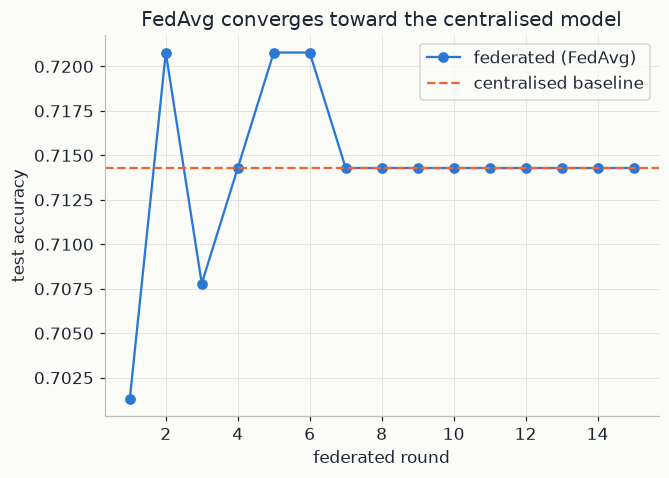

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(range(1, rounds + 1), history, color=mlutils.BLUE, marker="o", label="federated (FedAvg)")
ax.axhline(central_acc, color=mlutils.ORANGE, ls="--", label="centralised baseline")
ax.set(xlabel="federated round", ylabel="test accuracy", title="FedAvg converges toward the centralised model")
ax.legend()

No client's data was ever pooled, yet averaging local model updates over a handful of
rounds reaches accuracy close to the centralised model trained on all the data at
once. That's the entire promise of federated learning: the *statistical* result of
training on all the data, without the *logistical and privacy* cost of ever
collecting it in one place.

## Exercises

### Exercise 1: Fewer, larger clients vs. many small ones
Rerun with `np.array_split(shuffled, 10)` (10 clients instead of 3). Does convergence
speed (rounds needed to approach the centralised accuracy) change?

<details><summary>Solution</summary>

```python
client_indices_10 = np.array_split(shuffled, 10)
```
With more, smaller clients each local update is noisier (fewer local samples per
round), which typically means more rounds are needed to reach the same accuracy —
though each round is still cheap, since a client with less data also trains faster.
</details>

### Exercise 2: Non-IID clients
Instead of a random split, sort patients by `Age` before splitting into 3 clients, so
each client's local data distribution is systematically different (younger vs. older
patients). Does FedAvg still converge as smoothly?

<details><summary>Solution</summary>

```python
age_order = diabetes.drop(columns=["Outcome"]).values[:, 7].argsort()
```
Non-IID (non-identically-distributed) client data is one of federated learning's
hardest real-world problems: local updates can pull the global model in different
directions each round, and convergence is typically slower and less smooth than with
randomly (IID) split clients like the main example above.
</details>

## Key takeaways

- FedAvg trains a shared global model by repeatedly sending it to clients, training
  briefly on each client's local data only, and averaging the updated weights back on
  the server — the model moves, the raw data never does.
- Averaging is weighted by how much data each client contributes, matching what
  training on the pooled data would implicitly weight by.
- On data that's split randomly (IID) across clients, federated training can
  approach centralised accuracy in a modest number of rounds; genuinely non-IID
  client data (Exercise 2) is where federated learning gets substantially harder.